# Task
Train K-Nearest Neighbors, Decision Tree, and Naive Bayes classifiers on the Fashion MNIST dataset. Preprocess the data by flattening and normalizing images, then evaluate and compare the models using Accuracy and F1 scores. Finally, visualize the performance of each classifier by plotting confusion matrices for the test set.

## Load Fashion MNIST Dataset

### Subtask:
Load the Fashion MNIST dataset and prepare the training and testing sets for processing.


**Reasoning**:
I will load the Fashion MNIST dataset, verify its shape, and visualize sample images to ensure the data is correctly loaded and understood.



Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


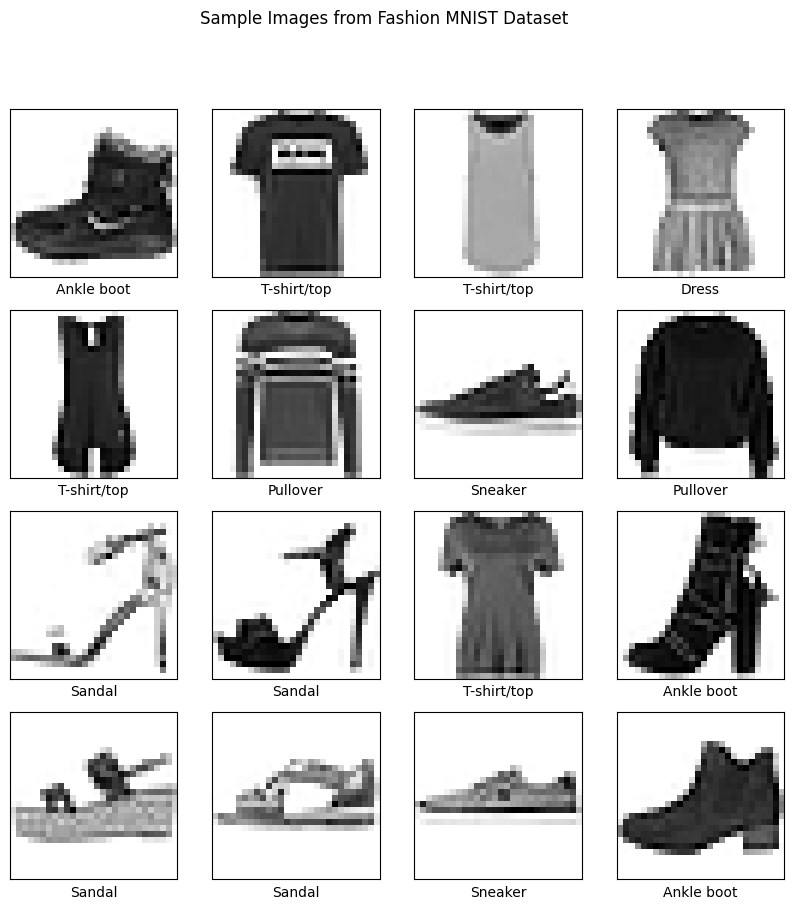

In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 2. Verify shapes
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Define class names for mapping labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 3. Display sample images
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.suptitle('Sample Images from Fashion MNIST Dataset')
plt.show()

## Data Preprocessing

### Subtask:
Flatten the image data and normalize pixel values to prepare the dataset for training the classifiers.


**Reasoning**:
I will flatten the image arrays and normalize the pixel values as requested in the subtask instructions.



In [3]:
# 1. Flatten the image data (28*28 = 784)
train_images_flat = train_images.reshape((train_images.shape[0], 28 * 28))
test_images_flat = test_images.reshape((test_images.shape[0], 28 * 28))

# 2. Normalize pixel values to be between 0 and 1
train_images_norm = train_images_flat.astype('float32') / 255.0
test_images_norm = test_images_flat.astype('float32') / 255.0

# 3. Print the new shapes to confirm
print(f"Flattened training images shape: {train_images_norm.shape}")
print(f"Flattened test images shape: {test_images_norm.shape}")

Flattened training images shape: (60000, 784)
Flattened test images shape: (10000, 784)


## Model Training

### Subtask:
Train K-Nearest Neighbors, Decision Tree, and Naive Bayes classifiers on the preprocessed training data.


**Reasoning**:
I will initialize and train the three specified classifiers (KNN, Decision Tree, and Naive Bayes) using the preprocessed training data as requested in the instructions.



In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Initialize the models
# Using n_neighbors=5 for KNN and random_state=42 for reproducibility in Decision Tree
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(random_state=42)
nb_model = GaussianNB()

# 2. Fit the models on the normalized and flattened training data
print("Training Naive Bayes...")
nb_model.fit(train_images_norm, train_labels)

print("Training Decision Tree...")
dt_model.fit(train_images_norm, train_labels)

print("Training K-Nearest Neighbors (this may take a few minutes)...")
knn_model.fit(train_images_norm, train_labels)

print("All models have been successfully trained.")

Training Naive Bayes...
Training Decision Tree...
Training K-Nearest Neighbors (this may take a few minutes)...
All models have been successfully trained.


## Model Evaluation

### Subtask:
Calculate Accuracy and F1 score for all three models to compare their classification performance.


**Reasoning**:
I will calculate the Accuracy and weighted F1 scores for the KNN, Decision Tree, and Naive Bayes models on the test set and display the results for comparison.



In [5]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# 1. Generate predictions for each model
knn_preds = knn_model.predict(test_images_norm)
dt_preds = dt_model.predict(test_images_norm)
nb_preds = nb_model.predict(test_images_norm)

# 2. Calculate metrics
results = {
    'Model': ['K-Nearest Neighbors', 'Decision Tree', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(test_labels, knn_preds),
        accuracy_score(test_labels, dt_preds),
        accuracy_score(test_labels, nb_preds)
    ],
    'F1 Score (Weighted)': [
        f1_score(test_labels, knn_preds, average='weighted'),
        f1_score(test_labels, dt_preds, average='weighted'),
        f1_score(test_labels, nb_preds, average='weighted')
    ]
}

# 3. Display the comparison table
results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df.to_string(index=False))

Model Performance Comparison:
              Model  Accuracy  F1 Score (Weighted)
K-Nearest Neighbors    0.8554             0.854644
      Decision Tree    0.7888             0.789665
        Naive Bayes    0.5856             0.556160


## Confusion Matrix Visualization

### Subtask:
Generate and plot confusion matrices for each model to visualize specific classification errors across different clothing categories.


**Reasoning**:
I will generate the Python code to visualize the confusion matrices for the three models (KNN, Decision Tree, and Naive Bayes) side-by-side using subplots as instructed.



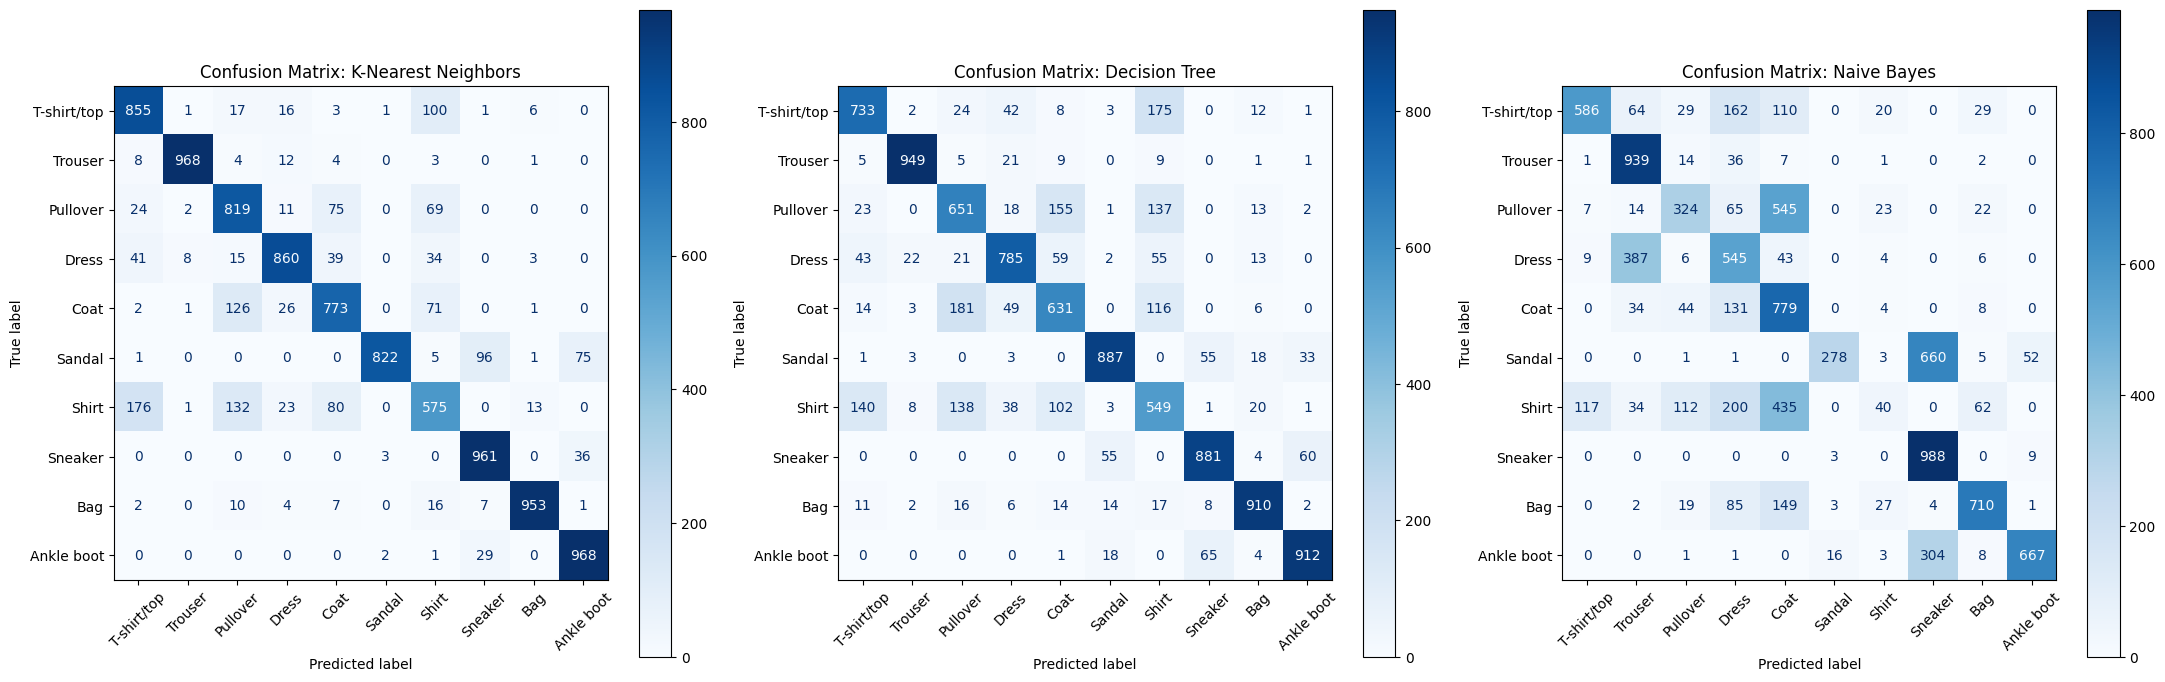

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# List of models, their predictions, and titles for iteration
models_info = [
    (test_labels, knn_preds, 'K-Nearest Neighbors'),
    (test_labels, dt_preds, 'Decision Tree'),
    (test_labels, nb_preds, 'Naive Bayes')
]

# 2. Compute and plot confusion matrices for each model
for i, (y_true, y_pred, title) in enumerate(models_info):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    # Plot on the specific subplot axis
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', xticks_rotation=45)
    axes[i].set_title(f'Confusion Matrix: {title}')

# 3. Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the performance of the three models on the Fashion MNIST dataset based on accuracy, F1 score, and the insights from the confusion matrices.


## Summary:

### Q&A

**How did the three models perform on the Fashion MNIST dataset?**
*   **K-Nearest Neighbors (KNN)** was the most effective model, achieving the highest accuracy (\$85.54\%\$) and F1 score (\$0.8546\$).
*   **Decision Tree** showed moderate performance with an accuracy of \$78.88\%\$ and an F1 score of \$0.7897\$.
*   **Naive Bayes** performed the poorest, with an accuracy of \$58.56\%\$ and an F1 score of \$0.5562\$, indicating it struggled to capture the complexity of the image data.

**What insights were gained from the confusion matrices?**
*   The confusion matrices highlighted specific misclassifications, such as frequent confusion between visually similar items like "Shirt," "T-shirt/top," and "Coat."
*   KNN showed the cleanest diagonal, indicating better precision across most classes compared to the other two models.
*   Naive Bayes exhibited high dispersion in its predictions, often misclassifying various items across multiple incorrect categories.

### Data Analysis Key Findings

*   **Dataset Prepared:** The Fashion MNIST dataset was successfully processed, involving the flattening of \$28 \times 28\$ images into \$784\$-feature vectors and scaling pixel values to a range of \$[0, 1]\$.
*   **KNN Superiority:** KNN outperformed the other models significantly, though it was the most computationally intensive during the prediction phase.
*   **Classification Challenges:** Across all models, "Shirts" were consistently the most difficult category to classify correctly, often being mistaken for "T-shirts," "Coats," or "Pullovers."
*   **Naive Bayes Limitations:** The Gaussian Naive Bayes model's assumption of independence between pixels likely led to its low accuracy (\$58.56\%\$), as it cannot capture the spatial relationships between pixels in an image.

### Insights or Next Steps

*   **Feature Engineering or Selection:** To improve the performance of simpler models like Naive Bayes or Decision Trees, consider using Dimensionality Reduction (e.g., PCA) to extract more meaningful features before training.
*   **Model Optimization:** For KNN, performing a grid search to find the optimal $k$ value could further improve accuracy, while for Decision Trees, pruning or using Random Forests could help reduce overfitting and improve generalization.


# Task
Serialize the trained `knn_model`, `dt_model`, and `nb_model` using the `pickle` library and save them to the local Colab directory as `knn_model.pkl`, `dt_model.pkl`, and `nb_model.pkl`. Once saved, initiate a download for each of these files to the local machine using `google.colab.files.download`.

## Serialize and Save Models

### Subtask:
Use the `pickle` library to save the trained `knn_model`, `dt_model`, and `nb_model` as .pkl files to the local Colab directory.


**Reasoning**:
I will use the `pickle` library to serialize the trained models (KNN, Decision Tree, and Naive Bayes) and save them as `.pkl` files to the local directory as requested in the instructions.



In [7]:
import pickle

# 1. Define filenames for the models
filenames = {
    'knn_model.pkl': knn_model,
    'dt_model.pkl': dt_model,
    'nb_model.pkl': nb_model
}

# 2. Serialize and save each model using a context manager to ensure file handles are closed
for filename, model in filenames.items():
    with open(filename, 'wb') as file:
        pickle.dump(model, file)
    print(f'Successfully saved {filename}')

print("All models have been serialized and saved to the local directory.")

Successfully saved knn_model.pkl
Successfully saved dt_model.pkl
Successfully saved nb_model.pkl
All models have been serialized and saved to the local directory.


## Download Model Files

### Subtask:
Use `google.colab.files.download` to trigger a browser download for each of the saved .pkl files so they can be stored locally.


**Reasoning**:
I will import the google.colab.files module and use it to download the three serialized model files to the local machine as specified in the instructions.



In [10]:
from google.colab import files

# 1. Define the list of model filenames
model_files = ["knn_model.pkl", "dt_model.pkl", "nb_model.pkl"]

# 2. Iterate and trigger downloads
print("Initiating downloads for model files...")
for filename in model_files:
    files.download(filename)
    print(f"Download triggered for: {filename}")

Initiating downloads for model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for: knn_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for: dt_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for: nb_model.pkl
